In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
import xgboost as xgb

import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use('ggplot')
sns.set_palette("muted")

In [3]:
basedf = pd.read_csv('/kaggle/input/competitions/fraud-detection-cpe-232-data-models/train.csv')

In [4]:
df =basedf

In [5]:
def clean(df):
    df['transac_type'] = df['transac_type'].fillna("UNKNOWN")
    return df

In [6]:
df = clean(df)

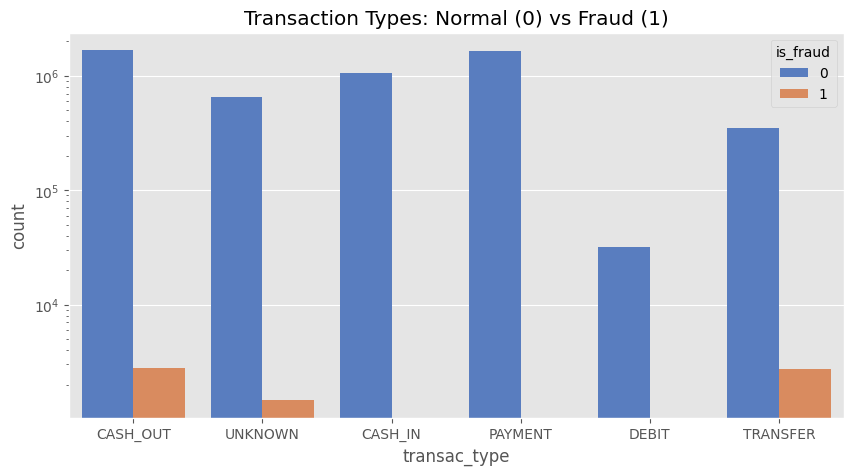

จำนวนเคส Fraud แบ่งตามประเภทธุรกรรม:
transac_type
CASH_OUT    2789
TRANSFER    2731
UNKNOWN     1461
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='transac_type', hue='is_fraud')
plt.title('Transaction Types: Normal (0) vs Fraud (1)')
plt.yscale('log')
plt.show()

print(df[df['is_fraud'] == 1]['transac_type'].value_counts())

In [35]:
missing_cols = ['transac_type', 'amount', 'src_bal', 'dst_bal']
miss_pattern = df[missing_cols].isnull()
print('Missing pattern overlap:')
print(miss_pattern.sum(axis=1).value_counts().sort_index())

Missing pattern overlap:
0    4881781
1     512902
2      13544
Name: count, dtype: int64


In [8]:
def cleaneda1(df):
    df = df.copy()

    df['transac_type'] = df['transac_type'].fillna('UNKNOWN')

    df['amount_is_missing']  = df['amount'].isna().astype(int)
    df['src_bal_is_missing'] = df['src_bal'].isna().astype(int)
    df['dst_bal_is_missing'] = df['dst_bal'].isna().astype(int)

    df['src_drained'] = (df['src_new_bal'] == 0).astype(int)
    df['dst_drained'] = (df['dst_new_bal'] == 0).astype(int)
    
    df['transac_type_TRANSFER']  = (df['transac_type'] == 'TRANSFER').astype(int)
    df['transac_type_CASH_OUT']  = (df['transac_type'] == 'CASH_OUT').astype(int)
    df['transac_type_UNKNOWN']   = (df['transac_type'] == 'UNKNOWN').astype(int)

    df.loc[df['amount'].isna(), 'amount'] = abs(df['src_new_bal'] - df['src_bal'])
    df['amount'] = df['amount'].fillna(
        df.groupby('transac_type')['amount'].transform('median')
    )
    
    df['src_bal'] = df['src_bal'].fillna(df['src_new_bal'] + df['amount'])
    df['dst_bal'] = df['dst_bal'].fillna(df['dst_new_bal'] - df['amount'])
    df['amount']  = df['amount'].fillna(-1)

    df['src_error'] = df['src_bal'] - df['amount'] - df['src_new_bal']
    df['dst_error'] = df['dst_bal'] + df['amount'] - df['dst_new_bal']

    df['hour']         = df['time_ind'] % 24
    df['day']          = df['time_ind'] // 24
    df['day_of_cycle'] = (df['time_ind'] // 24) % 7
    
    df['src_error_flag'] = (df['src_error'].abs() > 0.01).astype(int)
    df['dst_error_flag'] = (df['dst_error'].abs() > 0.01).astype(int)

    df['amount_to_src_ratio'] = np.where(
        df['src_bal'] > 0,
        df['amount'] / df['src_bal'], 0
    )
    return df

In [9]:
df =basedf
df = cleaneda1(df)

In [10]:
df.columns

Index(['id', 'time_ind', 'transac_type', 'amount', 'src_acc', 'src_bal',
       'src_new_bal', 'dst_acc', 'dst_bal', 'dst_new_bal', 'is_fraud',
       'is_flagged_fraud', 'amount_is_missing', 'src_bal_is_missing',
       'dst_bal_is_missing', 'src_drained', 'dst_drained',
       'transac_type_TRANSFER', 'transac_type_CASH_OUT',
       'transac_type_UNKNOWN', 'src_error', 'dst_error', 'hour', 'day',
       'day_of_cycle', 'src_error_flag', 'dst_error_flag',
       'amount_to_src_ratio'],
      dtype='object')

In [11]:
features = [
    'amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal',
    'amount_is_missing', 'src_bal_is_missing', 'dst_bal_is_missing',
    'transac_type_TRANSFER', 'transac_type_CASH_OUT', 'transac_type_UNKNOWN',
    'src_error', 'dst_error',
    'src_error_flag', 'dst_error_flag',
    'amount_to_src_ratio',
    'src_drained', 'dst_drained',
    'hour', 'day', 'day_of_cycle',
]

In [12]:

X = df[features]
y = df['is_fraud']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  #
)

print(f"Training Fraud Cases: {y_train.sum()}")
print(f"Testing Fraud Cases: {y_test.sum()}")

Training Fraud Cases: 5585
Testing Fraud Cases: 1396


In [14]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = xgb.XGBClassifier(
    n_estimators=400,         
    max_depth=10,              
    learning_rate=0.1,         
    scale_pos_weight=scale_weight,
    
    tree_method='hist',  
    device='cuda',           
   # n_jobs=-1,
    random_state=42,
    eval_metric='aucpr',
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=50                 
)

[0]	validation_0-aucpr:0.93775	validation_1-aucpr:0.93259
[50]	validation_0-aucpr:0.99852	validation_1-aucpr:0.98482
[100]	validation_0-aucpr:0.99990	validation_1-aucpr:0.98652
[150]	validation_0-aucpr:0.99999	validation_1-aucpr:0.98706
[200]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98799
[250]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98857
[300]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98893
[350]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98924
[399]	validation_0-aucpr:1.00000	validation_1-aucpr:0.98930


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
from sklearn.metrics import precision_recall_curve
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
clf.set_params(device='cpu')
y_probs_rf = clf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_rf)


f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = f1_scores[optimal_idx]

print(f"Threshold: {optimal_threshold:.4f}")
print(f"F1-Score: {max_f1:.4f}")

y_pred_optimal = (y_probs_rf >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

Threshold: 0.9754
F1-Score: 0.9837
[[1080243       7]
 [     38    1358]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1080250
           1       0.99      0.97      0.98      1396

    accuracy                           1.00   1081646
   macro avg       1.00      0.99      0.99   1081646
weighted avg       1.00      1.00      1.00   1081646



In [16]:
test_df = pd.read_csv('/kaggle/input/competitions/fraud-detection-cpe-232-data-models/test.csv')
submit = pd.read_csv('/kaggle/input/competitions/fraud-detection-cpe-232-data-models/sample_submission.csv')

In [17]:
test_df = cleaneda1(test_df)
X_test_final = test_df[features]

In [18]:
probs = clf.predict_proba(X_test_final)[:, 1]


threshold = optimal_threshold
final_preds = (probs >= threshold).astype(int)
submit['is_fraud'] = final_preds

In [19]:
submit.to_csv('v5.csv', index=False)

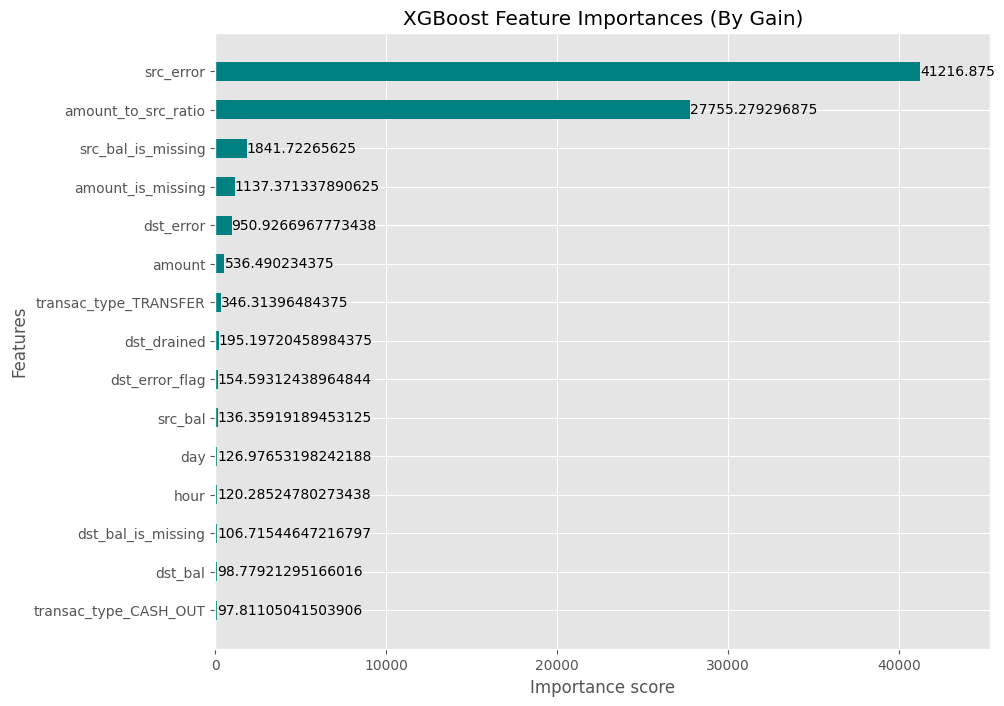

--- ตารางจัดอันดับความสำคัญของ Feature (0.0 - 1.0) ---
                  Feature  Importance
0               src_error    0.548763
1     amount_to_src_ratio    0.369535
2      src_bal_is_missing    0.024521
3       amount_is_missing    0.015143
4               dst_error    0.012661
5                  amount    0.007143
6   transac_type_TRANSFER    0.004611
7             dst_drained    0.002599
8          dst_error_flag    0.002058
9                 src_bal    0.001815
10                    day    0.001691
11                   hour    0.001601
12     dst_bal_is_missing    0.001421
13                dst_bal    0.001315
14  transac_type_CASH_OUT    0.001302
15            dst_new_bal    0.001045
16            src_new_bal    0.000714
17   transac_type_UNKNOWN    0.000645
18         src_error_flag    0.000518
19           day_of_cycle    0.000470
20            src_drained    0.000430


In [33]:


plt.rcParams['figure.figsize'] = (10, 8)

xgb.plot_importance(clf, max_num_features=15, height=0.5, importance_type='gain', color='teal')
plt.title('XGBoost Feature Importances (By Gain)')
plt.show()

feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_imp = feature_imp.reset_index(drop=True)

print("--- ตารางจัดอันดับความสำคัญของ Feature (0.0 - 1.0) ---")
print(feature_imp)